# Projet Airbnb - Prédiction du prix de location

**Objectif :** Prédire le logarithme du prix **"log_price"** d'un logement Airbnb à partir de ses caractéristiques.

**Métrique d'évaluation :** R² (coefficient de détermination)

---

## Plan du notebook

1. **Exploration qualitative** - comprendre les données et motiver nos choix de features
2. **Feature Engineering** - transformer les données brutes en features utilisables
3. **Modélisation** - tester et comparer plusieurs modèles
4. **Prédiction finale** - générer le fichier de soumission

In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

---
# PARTIE 1 - Exploration Qualitative des Données

Cette section vise à comprendre la structure des données, identifier les valeurs manquantes, et repérer les corrélations qui guideront nos choix de features.

## 1.1 Chargement et présentation générale

In [136]:
df = pd.read_csv('airbnb_train.csv')
df_test = pd.read_csv('airbnb_test.csv')

print(f'Données d\'entraînement : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')
print(f'Données de test        : {df_test.shape[0]:,} lignes x {df_test.shape[1]} colonnes')
df.head(3)

Données d'entraînement : 22,234 lignes x 28 colonnes
Données de test        : 51,877 lignes x 27 colonnes


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5708593,4.317488,House,Private room,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",3,1.0,Real Bed,flexible,False,...,NaN,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0
1,14483613,4.007333,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",4,2.0,Real Bed,strict,False,...,2017-09-17,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to...",Ridgewood,38,86.0,11385,1.0,2.0
2,10412649,7.090077,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",6,2.0,Real Bed,flexible,False,...,NaN,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0


In [137]:
# Types de chaque colonne
df.dtypes.to_frame('dtype').T

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
dtype,int64,float64,object,object,object,int64,float64,object,object,bool,...,object,float64,float64,object,object,int64,float64,object,float64,float64


In [138]:
# Statistiques descriptive 
df.describe().round(2)

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,22234.00,22234.00,22234.00,22183.00,22234.00,22234.00,22234.00,17256.00,22208.00,22199.00
mean,11222692.18,4.78,3.16,1.24,38.46,-92.27,20.67,94.07,1.26,1.71
std,6080480.28,0.72,2.14,0.59,3.07,21.67,37.18,7.78,0.85,1.25
min,3362.00,2.30,1.00,0.00,33.34,-122.51,0.00,20.00,0.00,0.00
25%,6202924.25,4.32,2.00,1.00,34.14,-118.34,1.00,92.00,1.00,1.00
50%,12174250.00,4.70,2.00,1.00,40.66,-76.99,6.00,96.00,1.00,1.00
75%,16395021.50,5.22,4.00,1.00,40.75,-73.95,23.00,100.00,1.00,2.00
max,21204503.00,7.60,16.00,8.00,42.39,-70.99,505.00,100.00,10.00,18.00


### Valeurs manquantes

In [139]:
# Calcul du pourcentage de valeurs manquantes par colonne
nulls = df.isnull().mean().sort_values(ascending=False) * 100
nulls = nulls[nulls > 0]
print(nulls.to_frame('% manquant').to_string())

                        % manquant
host_response_rate       24.624449
review_scores_rating     22.389134
first_review             21.251237
last_review              21.210758
neighbourhood             9.382028
zipcode                   1.362778
host_identity_verified    0.251867
host_since                0.251867
host_has_profile_pic      0.251867
bathrooms                 0.229378
beds                      0.157417
bedrooms                  0.116938


**Observations :**
- **host_response_rate**, **review_scores_rating**, **first_review**, **last_review** ont 22-25% de valeurs manquantes : probablement des logements récents sans avis.
- **neighbourhood** manque à 9% : sera encodé avec une catégorie "Other" pour les cas rares.
- **bathrooms**, **bedrooms**, **beds** ont très peu de NaN (<1%) : on imputera par la médiane.

---
## 1.2 Analyse de la variable cible : **log_price**

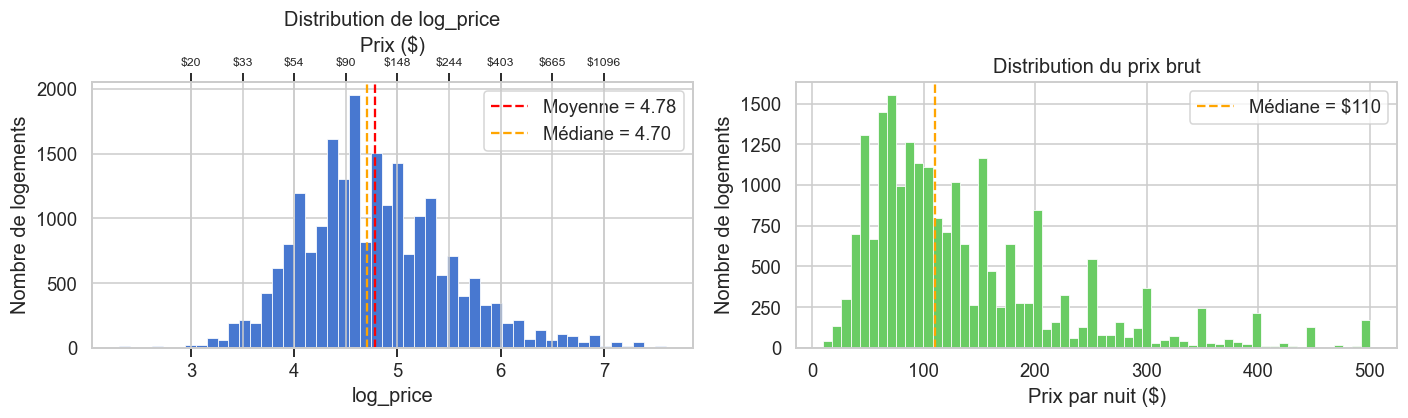

Prix min    : $10     (log = 2.30)
Prix max    : $1999   (log = 7.60)
Prix médian : $110    (log = 4.70)
Prix moyen  : $120    (log = 4.78)


In [140]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df['log_price'], bins=50, color=sns.color_palette('muted')[0], edgecolor='white', linewidth=0.5)
axes[0].axvline(df['log_price'].mean(), color='red', linestyle='--', label=f'Moyenne = {df["log_price"].mean():.2f}')
axes[0].axvline(df['log_price'].median(), color='orange', linestyle='--', label=f'Médiane = {df["log_price"].median():.2f}')
axes[0].set_xlabel('log_price')
axes[0].set_ylabel('Nombre de logements')
axes[0].set_title('Distribution de log_price')
axes[0].legend()

ax2 = axes[0].twiny()
ticks_log = [3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7]
ax2.set_xlim(axes[0].get_xlim())
ax2.set_xticks(ticks_log)
ax2.set_xticklabels([f'${int(np.exp(t))}' for t in ticks_log], fontsize=8)
ax2.set_xlabel('Prix ($)')

prix = np.exp(df['log_price'])
axes[1].hist(prix[prix < 500], bins=60, color=sns.color_palette('muted')[2], edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Prix par nuit ($)')
axes[1].set_ylabel('Nombre de logements')
axes[1].set_title('Distribution du prix brut')
axes[1].axvline(prix.median(), color='orange', linestyle='--', label=f'Médiane = ${prix.median():.0f}')
axes[1].legend()
 
plt.tight_layout()
plt.show()

print(f'Prix min    : ${np.exp(df["log_price"].min()):.0f}     (log = {df["log_price"].min():.2f})')
print(f'Prix max    : ${np.exp(df["log_price"].max()):.0f}   (log = {df["log_price"].max():.2f})')
print(f'Prix médian : ${np.exp(df["log_price"].median()):.0f}    (log = {df["log_price"].median():.2f})')
print(f'Prix moyen  : ${np.exp(df["log_price"].mean()):.0f}    (log = {df["log_price"].mean():.2f})')

**Observations :**
- Le **log_price** suit une distribution quasi-normale - idéal pour la régression.
- Le prix médian est d'environ 110$/nuit, avec une longue queue vers les prix élevés.
- Le log aplatie ces valeurs extrêmes, ce qui justifie son utilisation comme cible.

### Prix par **city** et **room_type**

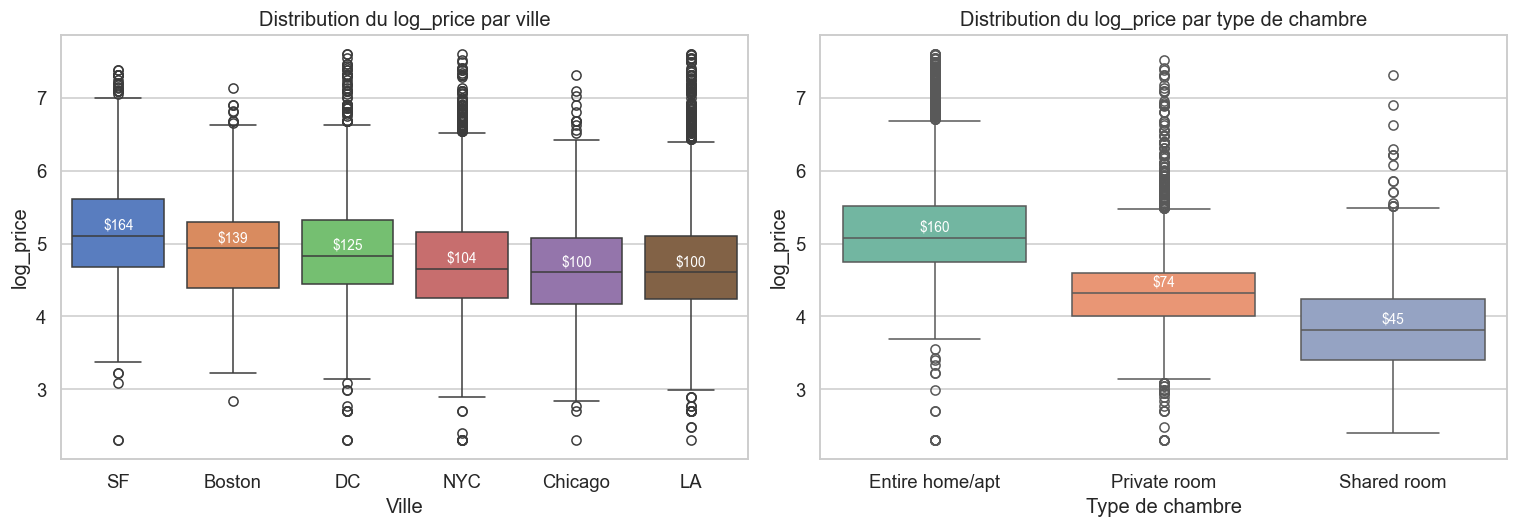

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

city_order = df.groupby('city')['log_price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='city', y='log_price', order=city_order, palette='muted', ax=axes[0])
axes[0].set_title('Distribution du log_price par ville')
axes[0].set_xlabel('Ville')
axes[0].set_ylabel('log_price')

medians = df.groupby('city')['log_price'].median()[city_order]
for i, (city, med) in enumerate(medians.items()):
    axes[0].text(i, med + 0.05, f'${int(np.exp(med))}', ha='center', va='bottom', fontsize=9, color='white')
    
room_order = df.groupby('room_type')['log_price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='room_type', y='log_price', order=room_order, palette='Set2', ax=axes[1])
axes[1].set_title('Distribution du log_price par type de chambre')
axes[1].set_xlabel('Type de chambre')
axes[1].set_ylabel('log_price')

medians2 = df.groupby('room_type')['log_price'].median()[room_order]
for i, room_type in enumerate(room_order):
    med = df[df['room_type'] == room_type]['log_price'].median()
    prix_usd = int(np.exp(med))
    axes[1].text(i, med + 0.10, f'${prix_usd}', ha='center', fontsize=9, color='white')
plt.tight_layout()
plt.show()

**Observations :**
- **San Francisco** est la ville la plus chère (~175$/nuit), suivie de New York (~120$).
- **Chicago** et **Boston** sont les moins chères.
- La variable **city** est très discriminante : à inclure dans le modèle.
- Un logement entier (*Entire home/apt*) coûte ~2× plus qu'une chambre privée (*Private room*) : **room_type** est une feature essentielle.

### Prix par **property_type**

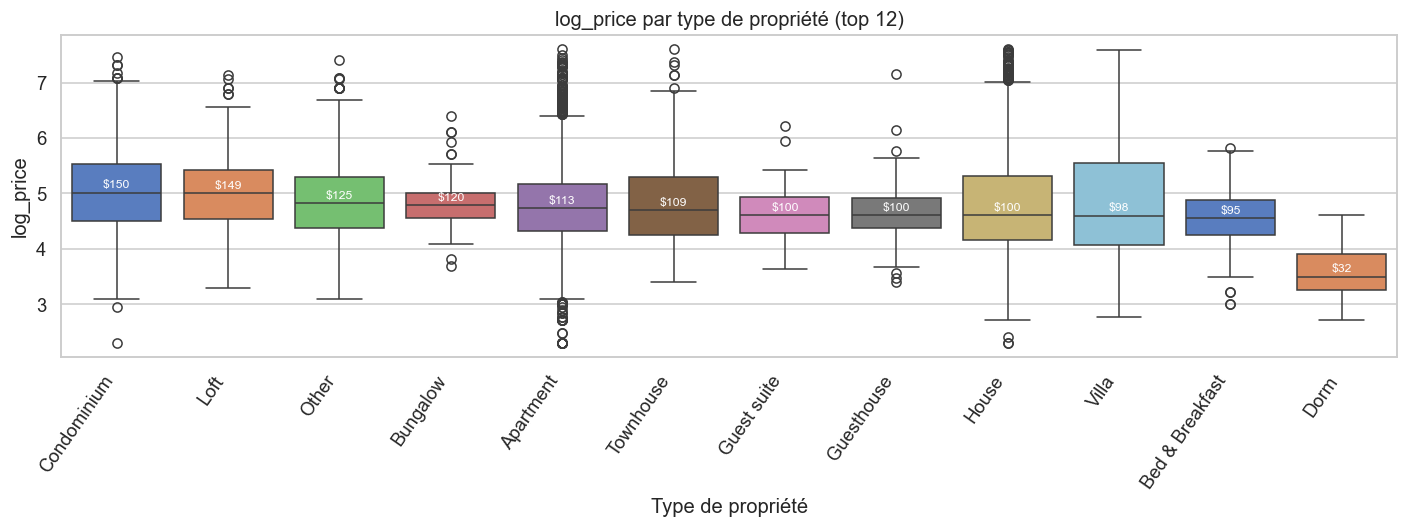

In [142]:
top_prop = df['property_type'].value_counts().head(12).index
df_prop = df[df['property_type'].isin(top_prop)]

prop_order = df_prop.groupby('property_type')['log_price'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df_prop, x='property_type', y='log_price', order=prop_order, palette='muted', ax=ax)
ax.set_title('log_price par type de propriété (top 12)')
ax.set_xlabel('Type de propriété')
ax.set_ylabel('log_price')
ax.set_xticklabels(ax.get_xticklabels(), rotation=55, ha='right')

medians3 = df_prop.groupby('property_type')['log_price'].median()[prop_order]
for i, (pt, med) in enumerate(medians3.items()):
    ax.text(i, med + 0.05, f'${int(np.exp(med))}', ha='center', va='bottom', fontsize=8, color='white')

plt.tight_layout()
plt.show()

**Observations :**
- Les villas, condominiums et chalets sont nettement plus chers.
- Les dortoirs (*Dorm*) et chambres d'hôtes (*Guesthouse*) sont les moins chers.
- **property_type** est une feature discriminante à conserver.

---
## 1.3 Exploration des variables catégorielles

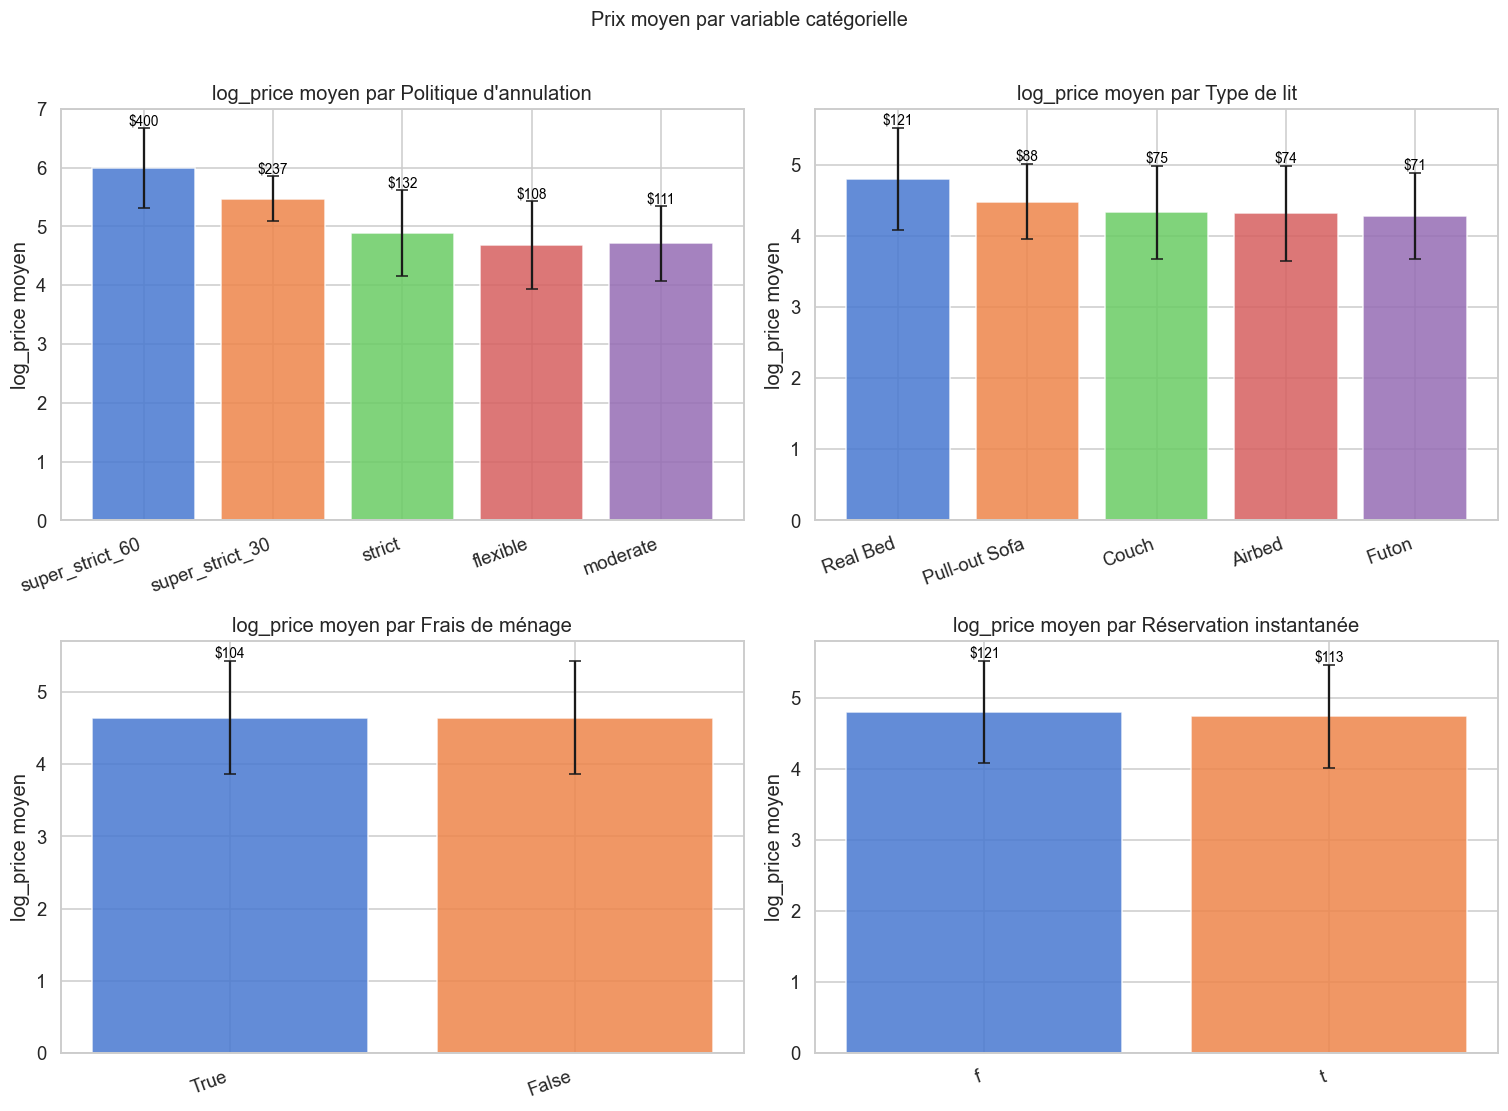

In [143]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cat_vars = ['cancellation_policy', 'bed_type', 'cleaning_fee', 'instant_bookable']
titles = ['Politique d\'annulation', 'Type de lit', 'Frais de ménage', 'Réservation instantanée']

for ax, col, title in zip(axes.flatten(), cat_vars, titles):
    order = df.groupby(col)['log_price'].median().sort_values(ascending=False).index
    means = df.groupby(col)['log_price'].mean()[order]
    stds = df.groupby(col)['log_price'].std()[order] 
    bars = ax.bar(range(len(order)), means, yerr=stds, capsize=4, color=sns.color_palette('muted'), alpha=0.85)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=20, ha='right')
    ax.set_title(f'log_price moyen par {title}')
    ax.set_ylabel('log_price moyen')
    for i, (m, s) in enumerate(zip(means, stds)):
        ax.text(i, m + s + 0.05, f'${int(np.exp(m))}', ha='center', fontsize=9, color='black')

plt.suptitle('Prix moyen par variable catégorielle', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

**Observations :**
- Les logements avec une politique **stricte** d'annulation sont plus chers (logements premium).
- Les **vrais lits** (*Real Bed*) dominent et sont associés aux prix les plus élevés.
- Les frais de ménage (**cleaning_fee = True**) corrèlent avec des prix plus élevés - logements plus professionnels.
- La réservation instantanée (**instant_bookable**) a un effet faible - variable moins discriminante.

---
## 1.4 Exploration des variables numériques

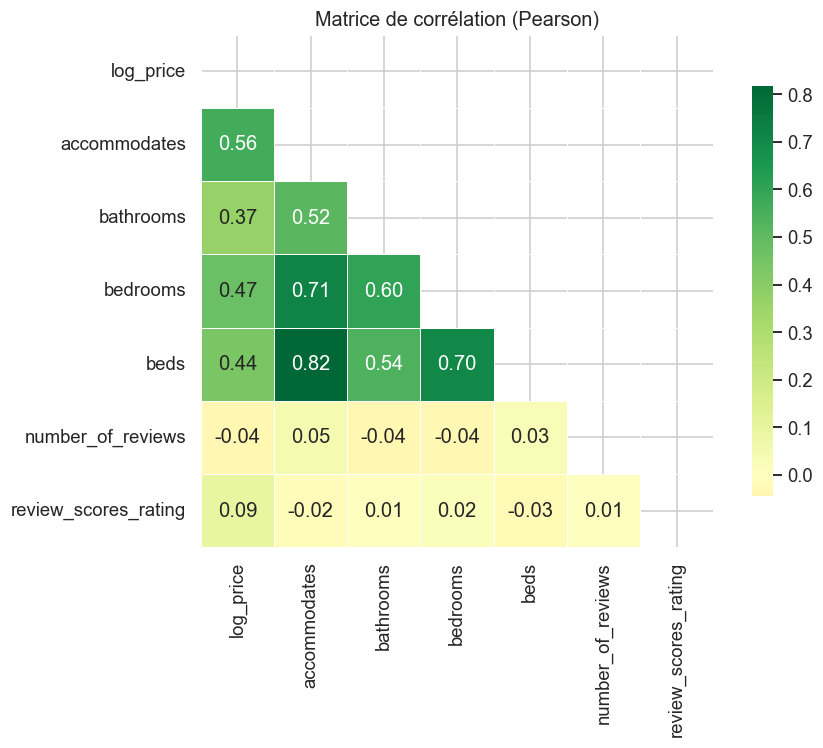

In [144]:
num_cols = ['log_price', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'number_of_reviews', 'review_scores_rating']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, mask=mask, ax=ax, square=True, cbar_kws={'shrink': 0.8}, linewidths=0.5)
ax.set_title('Matrice de corrélation (Pearson)', fontsize=13)
plt.tight_layout()
plt.show()

**Observations :**
- **accommodates**, **bathrooms**, **bedrooms**, **beds** ont une corrélation **positive** avec **log_price** (plus grand = plus cher).
- **accommodates** est la variable numérique la plus corrélée avec le prix (~0.45).
- **review_scores_rating** a une corrélation faible avec le prix - les mauvais logements n'ont pas forcément des prix faibles.
- **number_of_reviews** est quasi-indépendant du prix.

---
## 1.5 Exploration géographique

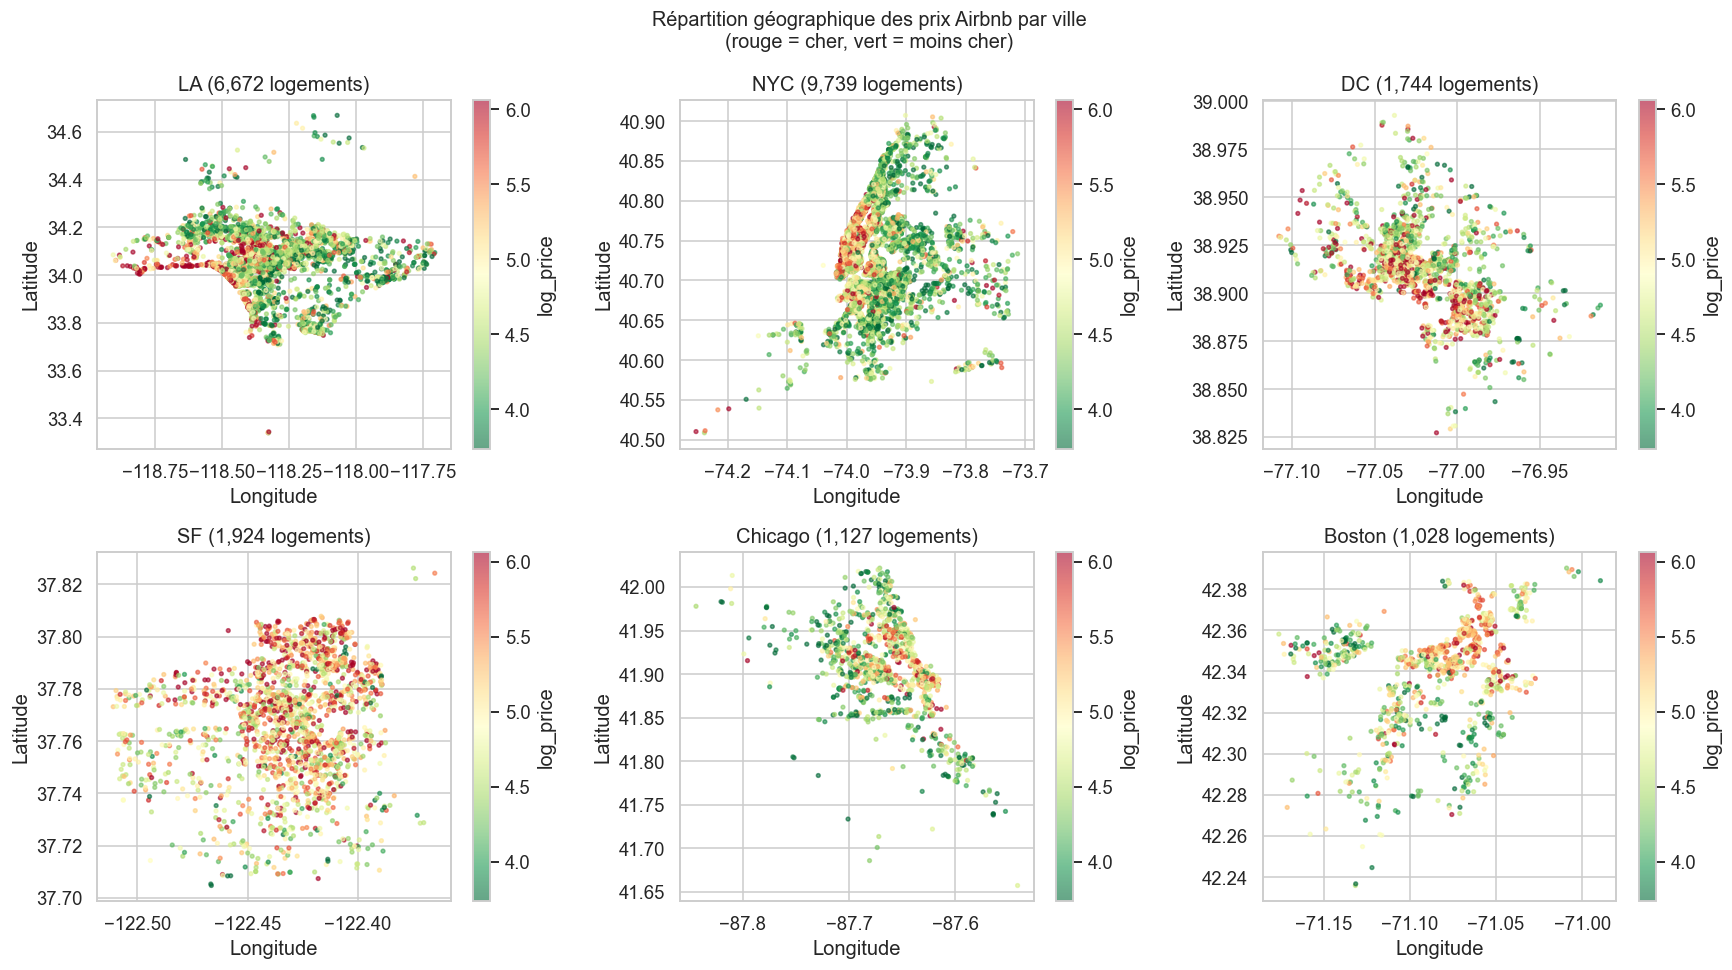

In [145]:
cities = df['city'].unique()
cols = 3
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4.5))
axes = axes.flatten()

cmap = plt.cm.RdYlGn_r

for i, city in enumerate(cities):
    df_city = df[df['city'] == city]
    sc = axes[i].scatter(
        df_city['longitude'], df_city['latitude'],
        c=df_city['log_price'], cmap=cmap, s=6, alpha=0.6,
        vmin=df['log_price'].quantile(0.05),
        vmax=df['log_price'].quantile(0.95)
    )
    axes[i].set_title(f'{city} ({len(df_city):,} logements)')
    axes[i].set_xlabel('Longitude')
    axes[i].set_ylabel('Latitude')
    plt.colorbar(sc, ax=axes[i], label='log_price')

plt.suptitle('Répartition géographique des prix Airbnb par ville\n(rouge = cher, vert = moins cher)', fontsize=13)
plt.tight_layout()
plt.show()

**Observations :**
- Dans chaque ville, les prix varient fortement selon la localisation géographique.
- À NYC, Manhattan (centre-gauche) concentre les logements les plus chers.
- À SF, le centre-ville et les quartiers nord sont les plus prisés.
- Les coordonnées **latitude/longitude** et le **quartier** (**neighbourhood**) ont donc un fort pouvoir prédictif : à inclure.

---
## 1.6 Exploration des amenities (équipements)

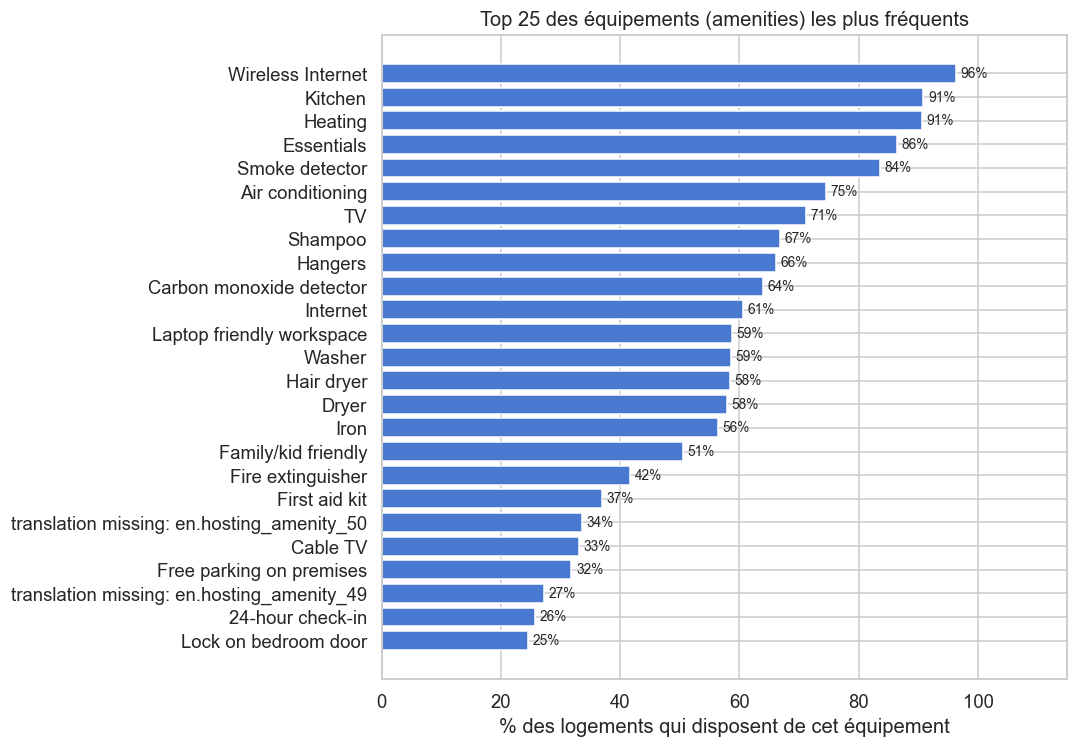

In [146]:
import re

def parse_amenities(amenity_str):
    if pd.isna(amenity_str):
        return []
    amenity_str = amenity_str.strip('{}')
    items = re.findall(r'"([^"]+)"|([^,]+)', amenity_str)
    return [a or b for a, b in items if (a or b).strip()]

all_amenities = df['amenities'].apply(parse_amenities)

from collections import Counter
amenity_counter = Counter(am for sublist in all_amenities for am in sublist)

top_amenities = pd.DataFrame(amenity_counter.most_common(25), columns=['amenity', 'count'])
top_amenities['pct'] = top_amenities['count'] / len(df) * 100

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top_amenities['amenity'][::-1], top_amenities['pct'][::-1], color=sns.color_palette('muted')[0])
ax.bar_label(bars, fmt='%.0f%%', padding=3, fontsize=9)
ax.set_xlabel('% des logements qui disposent de cet équipement')
ax.set_title('Top 25 des équipements (amenities) les plus fréquents')
ax.set_xlim(0, 115)
plt.tight_layout()
plt.show()

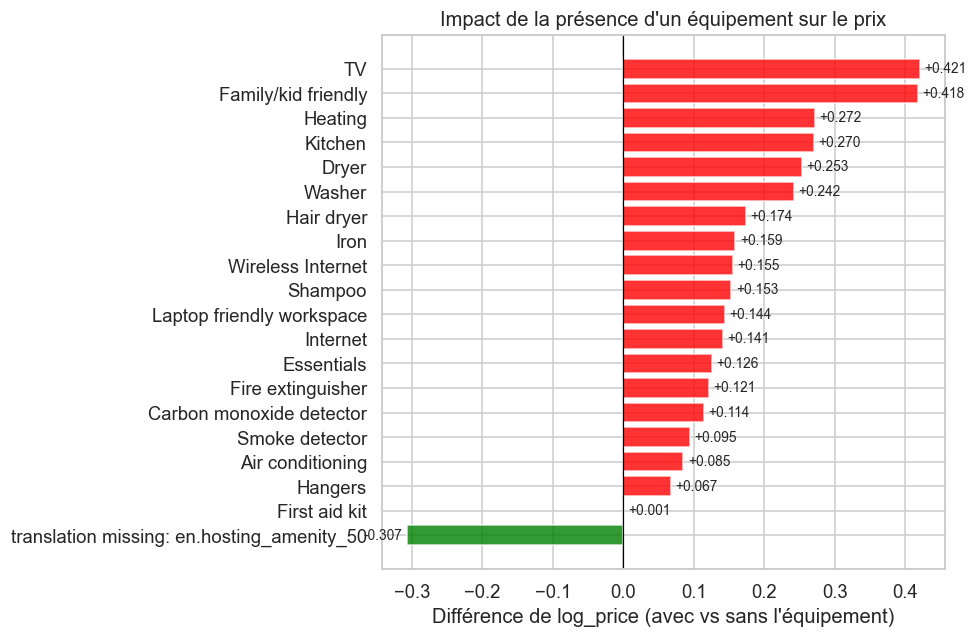

In [147]:
top20 = [am for am, _ in amenity_counter.most_common(20)]

impact = {}
for am in top20:
    has_am = all_amenities.apply(lambda lst: am in lst)
    price_with = df.loc[has_am, 'log_price'].mean()
    price_without = df.loc[~has_am, 'log_price'].mean()
    impact[am] = price_with - price_without

impact_df = pd.Series(impact).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['red' if v > 0 else 'green' for v in impact_df.values]
bars = ax.barh(impact_df.index, impact_df.values, color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.bar_label(bars, fmt='%+.3f', padding=3, fontsize=9)
ax.set_xlabel('Différence de log_price (avec vs sans l\'équipement)')
ax.set_title('Impact de la présence d\'un équipement sur le prix')
plt.tight_layout()
plt.show()

### À propos des "translation missing"

Les entrées "**translation missing: ...**" sont des **bugs de la plateforme Airbnb**. Elles apparaissent quand :
- Un équipement existe en base de données Airbnb
- Mais sa traduction en français n'est pas disponible
- La plateforme affiche alors un texte générique au lieu du vrai nom

Ces entrées n'ont aucune signification réelle donc on les exclut de l'analyse pour éviter de polluer les résultats.

### Analyse du graphique : Impact des équipements sur le prix

Le graphique montre **pour chaque équipement** la différence de prix entre :
- Les logements **qui ont** cet équipement
- Les logements **qui n'ont pas** cet équipement

**Interprétation des couleurs :**
- **Rouge (+)** : Cet équipement **augmente le prix** (logiquement : plus d'équipements = plus cher)
- **Vert (-)** : Cet équipement **diminue le prix** (paradoxe : possibilité qu'il soit plus fréquent dans les logements moins chers)

**Exemple concret :**
- Si "WiFi" = +0.25 : avoir WiFi augmente le log_price de 0.25 : prix réel × e^0.25 ≈ +28%

**Observation clé :**
- Presque **tous les équipements ont un impact positif**
- Le WiFi, climatisation, parking ont l'impact le plus fort
- Les équipements "basiques" (essentiels, détecteurs) ont moins d'impact : c'est attendu (ils sont partout)

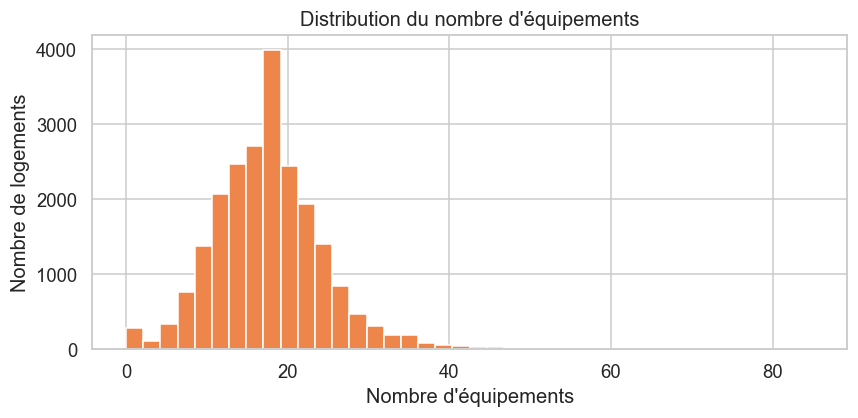

In [148]:
df['amenities_count'] = all_amenities.apply(len)

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['amenities_count'], bins=40, color=sns.color_palette('muted')[1], edgecolor='white')
ax.set_xlabel('Nombre d\'équipements')
ax.set_ylabel('Nombre de logements')
ax.set_title('Distribution du nombre d\'équipements')

plt.tight_layout()
plt.show()

---
## 1.7 Synthèse de l'exploration

| Feature | Type | Impact sur le prix |
|---|---|---|
| **city** | Catégorielle | Très fort |
| **room_type** | Catégorielle | Très fort |
| **property_type** | Catégorielle | Fort |
| **accommodates** | Numérique | Fort |
| **bathrooms** | Numérique | Fort |
| **bedrooms** | Numérique | Fort |
| **beds** | Numérique | Moyen |
| **cancellation_policy** | Catégorielle | Moyen |
| **cleaning_fee** | Booléen | Moyen |
| **amenities_count** | Numérique | Moyen |
| **latitude/longitude** | Numérique | Fort (géographie) |
| **neighbourhood** | Texte | Fort (localisation) |
| **host_response_rate** | Numérique | Faible |
| **review_scores_rating** | Numérique | Faible |
| **instant_bookable** | Booléen | Très faible |
| **number_of_reviews** | Numérique | Faible |
| **host_since**, **first_review**, **last_review** | Date | Moyen |
| **description**, **name** | Texte libre | Faible à moyen |

---
# PARTIE 2 - Feature Engineering & Prétraitement

L'exploration a montré quelles variables sont utiles. On va maintenant les transformer en features numériques exploitables par un algo de ML.

On crée une classe par type de transformation pour pouvoir appliquer exactement le même traitement sur le jeu de test.

## 2.1 Prétraitement de base - **BasePreprocessor**

Encode les variables catégorielles, convertit les booléens, et gère les valeurs manquantes.

In [149]:
from sklearn.preprocessing import LabelEncoder

class BasePreprocessor:

    def __init__(self):
        self.encoders = {}       
        self.medians = {}        
        self.fitted = False

    def fit_transform(self, df):
        self.fitted = True
        df = df.copy()

        bool_cols = ['instant_bookable', 'host_has_profile_pic', 'host_identity_verified']
        for col in bool_cols:
            df[col] = (df[col] == 't').astype(int)

        df['cleaning_fee'] = df['cleaning_fee'].astype(int)

        df['host_response_rate'] = (
            df['host_response_rate']
            .astype(str)
            .str.replace('%', '', regex=False)
            .replace('nan', float('nan'))
            .astype(float)
        )

        cat_cols = ['property_type', 'room_type', 'bed_type',
                    'cancellation_policy', 'city']
        for col in cat_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            self.encoders[col] = le

        for col in ['bathrooms', 'bedrooms', 'beds']:
            self.medians[col] = df[col].median()
            df[col] = df[col].fillna(self.medians[col])

        for col in ['review_scores_rating', 'host_response_rate']:
            self.medians[col] = df[col].median()
            df[col + '_is_null'] = df[col].isna().astype(int)
            df[col] = df[col].fillna(self.medians[col])

        return df

    def transform(self, df):
        assert self.fitted, "Appelle fit_transform sur le train avant transform."
        df = df.copy()

        bool_cols = ['instant_bookable', 'host_has_profile_pic', 'host_identity_verified']
        for col in bool_cols:
            df[col] = (df[col] == 't').astype(int)
        df['cleaning_fee'] = df['cleaning_fee'].astype(int)

        df['host_response_rate'] = (
            df['host_response_rate']
            .astype(str)
            .str.replace('%', '', regex=False)
            .replace('nan', float('nan'))
            .astype(float)
        )

        cat_cols = ['property_type', 'room_type', 'bed_type',
                    'cancellation_policy', 'city']
        for col in cat_cols:
            le = self.encoders[col]
            known = set(le.classes_)
            df[col] = df[col].astype(str).apply(
                lambda x: le.transform([x])[0] if x in known else len(le.classes_)
            )

        for col in ['bathrooms', 'bedrooms', 'beds']:
            df[col] = df[col].fillna(self.medians[col])

        for col in ['review_scores_rating', 'host_response_rate']:
            df[col + '_is_null'] = df[col].isna().astype(int)
            df[col] = df[col].fillna(self.medians[col])

        return df



### Test du **BasePreprocessor**

In [150]:
df_raw = pd.read_csv('airbnb_train.csv')

base_prep = BasePreprocessor()
df_base = base_prep.fit_transform(df_raw)

cols_check = ['bathrooms', 'bedrooms', 'beds', 'review_scores_rating', 'host_response_rate', 'cleaning_fee', 'instant_bookable']
print("NaN après BasePreprocessor :")
print(df_base[cols_check].isnull().sum().to_string())
print()
print("Aperçu des colonnes encodées :")
df_base[['property_type', 'room_type', 'city', 'cancellation_policy', 'review_scores_rating', 'review_scores_rating_is_null']].head(5)


NaN après BasePreprocessor :
bathrooms               0
bedrooms                0
beds                    0
review_scores_rating    0
host_response_rate      0
cleaning_fee            0
instant_bookable        0

Aperçu des colonnes encodées :


,property_type,room_type,city,cancellation_policy,review_scores_rating,review_scores_rating_is_null
0,16,1,3,0,96.0,1
1,16,1,4,2,86.0,0
2,0,0,2,0,96.0,1
3,16,1,4,0,96.0,0
4,16,0,5,1,96.0,0


## 2.2 Feature Engineering Amenities - **AmenitiesEncoder**

On extrait deux types de features depuis la colonne **amenities** :
- **amenities_count** : le nombre total d'équipements (corrélé au prix)
- **Features binaires** : 1 si l'équipement est présent, 0 sinon - pour les 20 amenities les plus fréquentes

On exclut les entrées **"translation missing: ..."** qui sont des bugs de la plateforme Airbnb.

In [151]:
import re
from collections import Counter

class AmenitiesEncoder:

    def __init__(self, top_n=20):
        self.top_n = top_n
        self.top_amenities = []  
        self.fitted = False

    @staticmethod
    def _parse(amenity_str):
        if pd.isna(amenity_str):
            return []
        amenity_str = str(amenity_str).strip('{}')
        items = re.findall(r'"([^"]+)"|([^,]+)', amenity_str)
        result = [a or b for a, b in items if (a or b).strip()]
        result = [a for a in result if not a.startswith('translation missing')]
        return result

    def fit_transform(self, df):
        self.fitted = True
        df = df.copy()

        all_parsed = df['amenities'].apply(self._parse)

        counter = Counter(am for lst in all_parsed for am in lst)
        self.top_amenities = [am for am, _ in counter.most_common(self.top_n)]

        return self._add_features(df, all_parsed)

    def transform(self, df):
        assert self.fitted
        df = df.copy()
        all_parsed = df['amenities'].apply(self._parse)
        return self._add_features(df, all_parsed)

    def _add_features(self, df, all_parsed):
        df['amenities_count'] = all_parsed.apply(len)

        for am in self.top_amenities:
            col_name = 'am_' + re.sub(r'[^a-z0-9]', '_', am.lower())
            df[col_name] = all_parsed.apply(lambda lst: int(am in lst))

        return df


## 2.3 Feature Engineering Temporel - **DateFeatures**

Les colonnes **host_since**, **first_review**, **last_review** sont des dates : on les transforme en **nombre de jours** par rapport à une date de référence.

In [152]:
class DateFeatures:

    def __init__(self, reference_date='2017-12-01'): # date max dans le jeu de données
        self.ref = pd.Timestamp(reference_date)
        self.medians = {}
        self.fitted = False

    def fit_transform(self, df):
        self.fitted = True
        df = df.copy()
        df = self._compute(df, fit=True)
        return df

    def transform(self, df):
        assert self.fitted
        df = df.copy()
        df = self._compute(df, fit=False)
        return df

    def _compute(self, df, fit):
        df['host_since'] = pd.to_datetime(df['host_since'], errors='coerce')
        df['host_experience_days'] = (self.ref - df['host_since']).dt.days

        df['first_review'] = pd.to_datetime(df['first_review'], errors='coerce')
        df['days_since_first_review'] = (self.ref - df['first_review']).dt.days

        df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
        df['days_since_last_review'] = (self.ref - df['last_review']).dt.days

        df['has_reviews'] = df['first_review'].notna().astype(int)

        for col in ['host_experience_days', 'days_since_first_review', 'days_since_last_review']:
            if fit:
                self.medians[col] = df[col].median()
            df[col] = df[col].fillna(self.medians[col])

        df = df.drop(columns=['host_since', 'first_review', 'last_review'], errors='ignore')

        return df



## 2.4 Feature Engineering Texte - **TextFeatures**

On extrait des informations simples depuis les colonnes texte **description** et **name** :
- La présence de **mots-clés premium** (luxury, penthouse, etc.)

In [153]:
class TextFeatures:

    LUXURY_KEYWORDS = ['luxury', 'penthouse', 'designer', 'premium', 'mansion', 'villa', 'rooftop', 'panoramic', 'exclusive']

    def fit_transform(self, df):
        return self.transform(df)

    def transform(self, df):
        df = df.copy()

        def has_luxury(row):
            text = (str(row.get('name', '')) + ' ' + str(row.get('description', ''))).lower()
            return int(any(kw in text for kw in self.LUXURY_KEYWORDS))

        df['has_luxury_keyword'] = df.apply(has_luxury, axis=1)

        df = df.drop(columns=['description', 'name'], errors='ignore')

        return df


## 2.5 Feature Engineering Géographique - **GeoFeatures**

- **latitude** et **longitude** sont gardés tels quels 
- **neighbourhood** : les quartiers très rares (<5 occurrences) sont regroupés en "Other"

In [154]:
class GeoFeatures:

    def __init__(self, min_count=5):
        self.min_count = min_count
        self.encoder = LabelEncoder()
        self.known_neighbourhoods = set()
        self.fitted = False

    def fit_transform(self, df):
        self.fitted = True
        df = df.copy()

        counts = df['neighbourhood'].value_counts()
        rare = counts[counts < self.min_count].index
        df['neighbourhood'] = df['neighbourhood'].fillna('Unknown')
        df.loc[df['neighbourhood'].isin(rare), 'neighbourhood'] = 'Other'

        self.known_neighbourhoods = set(df['neighbourhood'].unique())
        df['neighbourhood'] = self.encoder.fit_transform(df['neighbourhood'])

        return df

    def transform(self, df):
        assert self.fitted
        df = df.copy()
        df['neighbourhood'] = df['neighbourhood'].fillna('Unknown')
        df['neighbourhood'] = df['neighbourhood'].apply(
            lambda x: x if x in self.known_neighbourhoods else 'Other'
        )
        df['neighbourhood'] = self.encoder.transform(df['neighbourhood'])
        return df


## 2.6 Features Dérivées

On combine des variables existantes pour créer de nouvelles features potentiellement plus informatives.
- **beds_per_person** : indique le nombre de lit par personne, cela peut etre un indicateur de la qualité / taille du logement 
- **batherooms_per_person** : nous donne une indication sur la taille du logement 

In [155]:
def add_derived_features(df):
    df = df.copy()

    df['beds_per_person'] = df['beds'] / df['accommodates'].replace(0, 1)
    df['bathrooms_per_person'] = df['bathrooms'] / df['accommodates'].replace(0, 1)

    return df


## 2.7 Pipeline complet

On enchaîne toutes les transformations dans l'ordre et on définit la liste finale des features à utiliser.

In [156]:
def build_features(df, base_prep, amenities_enc, date_feats, text_feats, geo_feats, fit=False):
    if fit:
        df = base_prep.fit_transform(df)
        df = amenities_enc.fit_transform(df)
        df = date_feats.fit_transform(df)
        df = text_feats.fit_transform(df)
        df = geo_feats.fit_transform(df)
    else:
        df = base_prep.transform(df)
        df = amenities_enc.transform(df)
        df = date_feats.transform(df)
        df = text_feats.transform(df)
        df = geo_feats.transform(df)
    df = add_derived_features(df)
    return df

COLS_TO_DROP = ['id', 'log_price', 'amenities', 'zipcode']

def get_X(df):
    return df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns])



## 2.8 Application sur les données d'entraînement

In [157]:
df_raw = pd.read_csv('airbnb_train.csv')
df_test_raw = pd.read_csv('airbnb_test.csv')

base_prep     = BasePreprocessor()
amenities_enc = AmenitiesEncoder(top_n=20)
date_feats    = DateFeatures()
text_feats    = TextFeatures()
geo_feats     = GeoFeatures()

df_processed = build_features(df_raw, base_prep, amenities_enc, date_feats, text_feats, geo_feats, fit=True)

X = get_X(df_processed)
y = df_raw['log_price']

print(f"Shape de X : {X.shape}")
print(f"Nombre de features : {X.shape[1]}")
print(f"\nListe des features :")
for i, col in enumerate(X.columns):
    print(f"  {i+1:2d}. {col}")


Shape de X : (22234, 49)
Nombre de features : 49

Liste des features :
   1. property_type
   2. room_type
   3. accommodates
   4. bathrooms
   5. bed_type
   6. cancellation_policy
   7. cleaning_fee
   8. city
   9. host_has_profile_pic
  10. host_identity_verified
  11. host_response_rate
  12. instant_bookable
  13. latitude
  14. longitude
  15. neighbourhood
  16. number_of_reviews
  17. review_scores_rating
  18. bedrooms
  19. beds
  20. review_scores_rating_is_null
  21. host_response_rate_is_null
  22. amenities_count
  23. am_wireless_internet
  24. am_kitchen
  25. am_heating
  26. am_essentials
  27. am_smoke_detector
  28. am_air_conditioning
  29. am_tv
  30. am_shampoo
  31. am_hangers
  32. am_carbon_monoxide_detector
  33. am_internet
  34. am_laptop_friendly_workspace
  35. am_washer
  36. am_hair_dryer
  37. am_dryer
  38. am_iron
  39. am_family_kid_friendly
  40. am_fire_extinguisher
  41. am_first_aid_kit
  42. am_cable_tv
  43. host_experience_days
  44. days_s

In [158]:
nan_count = X.isnull().sum().sum()
print(f"NaN restants dans X : {nan_count}")
if nan_count > 0:
    print("Colonnes avec NaN :")
    print(X.isnull().sum()[X.isnull().sum() > 0])
else:
    print("Parfait - X est prêt pour l'entraînement.")


NaN restants dans X : 0
Parfait - X est prêt pour l'entraînement.


---
# PARTIE 3 - Expériences de Modélisation

On teste plusieurs combinaisons de features et de modèles de façon progressive.  
Pour chaque expérience on note le **R² en entraînement** et le **R² en validation** (split 75/25).

- Un R² train très élevé mais un R² test faible = **overfitting** (le modèle a mémorisé le train mais ne généralise pas)
- Un bon modèle a des scores train et test proches et élevés

## 3.0 Préparation - Split train / validation

In [159]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.svm import LinearSVR
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

df_raw = pd.read_csv('airbnb_train.csv')

base_prep     = BasePreprocessor()
amenities_enc = AmenitiesEncoder(top_n=20)
date_feats    = DateFeatures()
text_feats    = TextFeatures()
geo_feats     = GeoFeatures()

df_processed = build_features(df_raw, base_prep, amenities_enc, date_feats, text_feats, geo_feats, fit=True)
X_full = get_X(df_processed)
y = df_raw['log_price']

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y, test_size=0.25, random_state=98
)

print(f"Train : {X_train.shape[0]:,} lignes | Test : {X_val.shape[0]:,} lignes")
print(f"Nombre de features : {X_full.shape[1]}")

results = {}
def eval_model(name, model, X_tr, X_v, y_tr=y_train, y_v=y_val):
    r2_tr  = r2_score(y_tr, model.predict(X_tr))
    r2_val = r2_score(y_v,  model.predict(X_v))
    results[name] = (r2_tr, r2_val)
    print(f"  R² train : {r2_tr:.4f}  |  R² test : {r2_val:.4f}")
    return r2_tr, r2_val

Train : 16,675 lignes | Test : 5,559 lignes
Nombre de features : 49


## Expérience 1 - Baseline

Reproduction exacte du notebook example : **LinearSVR** avec seulement 3 features.  
Sert de référence pour mesurer les gains des expériences suivantes.

In [160]:
print("Expérience 1 : Baseline (LinearSVR, 3 features)")

X1_train = X_train[['property_type', 'accommodates', 'bathrooms']]
X1_val   = X_val[['property_type',   'accommodates', 'bathrooms']]

m1 = LinearSVR(max_iter=2000)
m1.fit(X1_train, y_train)
eval_model('Exp1 — Baseline (LinearSVR, 3 features)', m1, X1_train, X1_val)


Expérience 1 : Baseline (LinearSVR, 3 features)
  R² train : 0.3251  |  R² test : 0.3325


(0.32513254614198817, 0.3324718731441356)

## Expérience 2 - Feature set complet - Comparaison de modèles

On utilise **toutes les features** disponibles et on compare 5 modèles différents sur exactement le même jeu de données pour identifier le meilleur.

In [161]:
print("Expérience 2 : Feature set complet - Comparaison de modèles")

models_to_test = {
    'Ridge':                Ridge(alpha=1.0),
    'RandomForest (100)':   RandomForestRegressor(n_estimators=100, random_state=98, n_jobs=-1),
    'GradientBoosting':     GradientBoostingRegressor(n_estimators=200, random_state=98),
    'HistGradientBoosting': HistGradientBoostingRegressor(max_iter=300, random_state=98),
    'KNeighbors (k=10)':    KNeighborsRegressor(n_neighbors=10, n_jobs=-1),
}

for name, model in models_to_test.items():
    print(f"  {name} : ")
    model.fit(X_train, y_train)
    eval_model(f'Exp2 — {name}', model, X_train, X_val)

Expérience 2 : Feature set complet - Comparaison de modèles
  Ridge : 
  R² train : 0.5865  |  R² test : 0.5809
  RandomForest (100) : 
  R² train : 0.9559  |  R² test : 0.6784
  GradientBoosting : 
  R² train : 0.7230  |  R² test : 0.6880
  HistGradientBoosting : 
  R² train : 0.8212  |  R² test : 0.7060
  KNeighbors (k=10) : 
  R² train : 0.1673  |  R² test : -0.0288


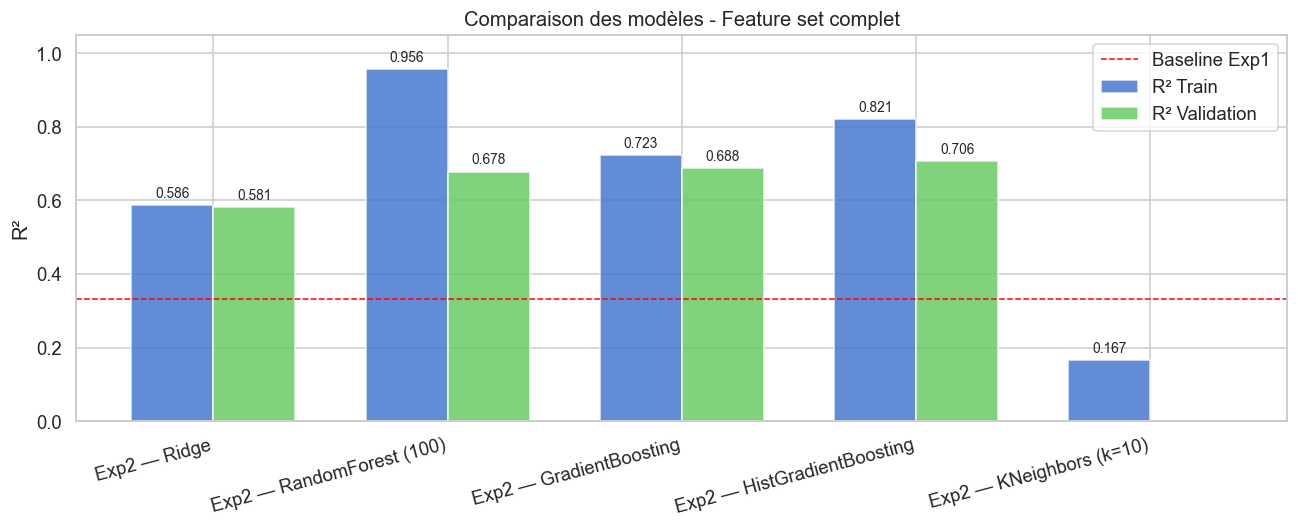

In [162]:
exp2_results = {k.replace('Exp2 - ', ''): v for k, v in results.items() if k.startswith('Exp2')}
labels    = list(exp2_results.keys())
r2_trains = [v[0] for v in exp2_results.values()]
r2_vals   = [v[1] for v in exp2_results.values()]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, r2_trains, width, label='R² Train',      color=sns.color_palette('muted')[0], alpha=0.85)
bars2 = ax.bar(x + width/2, r2_vals,   width, label='R² Validation', color=sns.color_palette('muted')[2], alpha=0.85)

ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('R²')
ax.set_ylim(0, 1.05)
ax.set_title('Comparaison des modèles - Feature set complet')
ax.legend()
ax.axhline(results['Exp1 — Baseline (LinearSVR, 3 features)'][1], color='red', linestyle='--', linewidth=1, label='Baseline Exp1')
ax.legend()
plt.tight_layout()
plt.show()

**Analyse comparative :**
- **Ridge** : modèle linéaire, sous-performe car les relations prix-features sont non-linéaires.
- **RandomForest** : excellent sur le train mais sur-apprend significativement (écart train/val notable), ce qui réduit sa capacité à généraliser.
- **GradientBoosting** : bon équilibre train/val, légèrement moins bon que HistGradientBoosting.
- **HistGradientBoosting** : meilleur R² de validation et overfitting le plus faible : **modèle retenu pour la Partie 4**.
- **KNeighbors** : très mauvais en validation : la distance euclidienne en haute dimension n'est pas pertinente (*curse of dimensionality*).

## Feature Importance - RandomForest

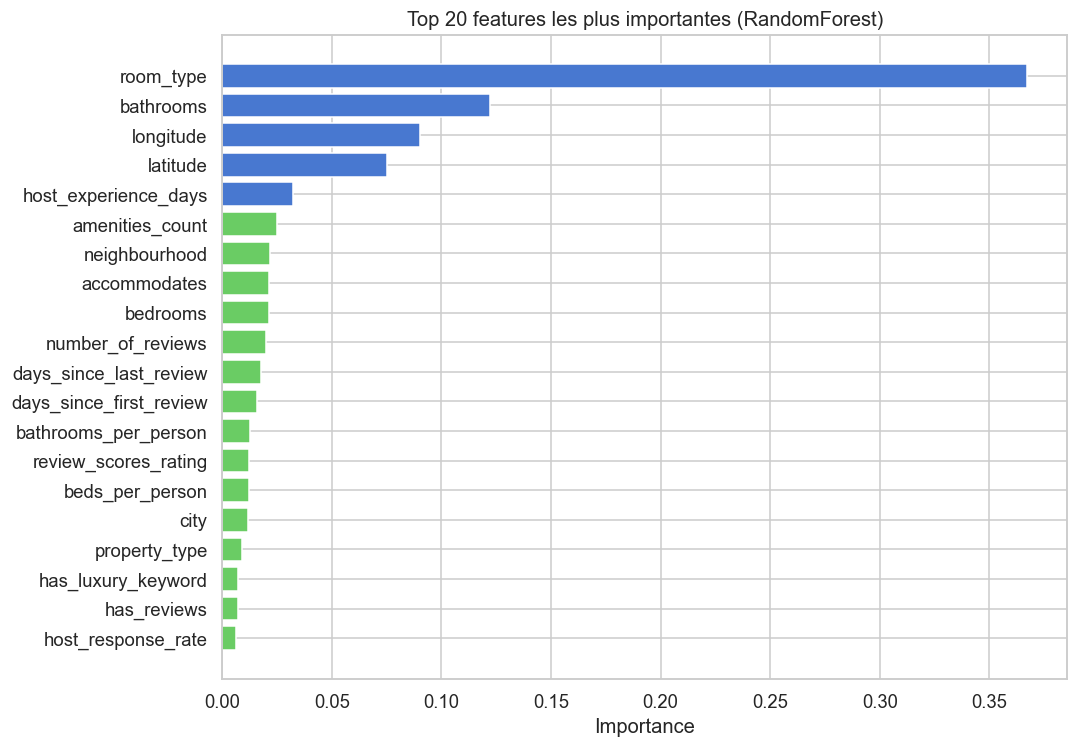

In [163]:
rf_for_importance = models_to_test['RandomForest (100)']
importances = pd.Series(rf_for_importance.feature_importances_, index=X_full.columns)
importances = importances.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [sns.color_palette('muted')[0] if i < 5 else sns.color_palette('muted')[2]
          for i in range(len(importances))]
ax.barh(importances.index[::-1], importances.values[::-1], color=colors[::-1])
ax.set_xlabel('Importance')
ax.set_title('Top 20 features les plus importantes (RandomForest)')
plt.tight_layout()
plt.show()

**Analyse des features importantes :**
- **room_type**, **accommodates**, **bedrooms**, **bathrooms** dominent : la taille et le type du logement sont les premiers déterminants du prix.
- **latitude**, **longitude**, **city**, **neighbourhood** : la géographie est essentielle.
- **amenities_count** confirme son utilité : les équipements influencent bien le prix.
- Les features temporelles (**host_experience_days**, **days_since_last_review**) contribuent modestement mais apportent un signal utile.
- Le feature engineering a payé : le R² de validation est bien supérieur à la baseline (~0.32).

---
# PARTIE 4 - Optimisation & Prédiction Finale

On optimise **HistGradientBoostingRegressor** (meilleur modèle de la Partie 3) avec **RandomizedSearchCV**, puis on génère le fichier de soumission.

## 4.1 Optimisation des hyperparamètres

**RandomizedSearchCV** teste 20 combinaisons d'hyperparamètres aléatoires, évaluées par cross-validation à 5 folds.

In [164]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'max_iter':          [200, 300, 400, 500],
    'learning_rate':     [0.03, 0.05, 0.07, 0.1, 0.15],
    'max_depth':         [3, 4, 5, 6, None],
    'min_samples_leaf':  [10, 20, 30, 40],
    'max_leaf_nodes':    [15, 20, 31, 40, None],
    'l2_regularization': [0.0, 0.1, 0.5, 1.0],
}

search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=98),
    param_distributions=param_dist,
    n_iter=20, cv=5,
    scoring='r2', n_jobs=-1, random_state=98,
    verbose=1
)
search.fit(X_train, y_train)

print("\nMeilleurs hyperparamètres :", search.best_params_)
best_model = search.best_estimator_
eval_model('Optimisé - HistGradBoost (RandomizedSearchCV)', best_model, X_train, X_val)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Meilleurs hyperparamètres : {'min_samples_leaf': 40, 'max_leaf_nodes': 31, 'max_iter': 500, 'max_depth': None, 'learning_rate': 0.05, 'l2_regularization': 0.0}
  R² train : 0.7796  |  R² test : 0.7077


(0.7795690900043893, 0.7077040906018017)

## 4.2 Analyse des résidus

On vérifie que les erreurs du modèle sont centrées autour de 0 et distribuées normalement - signe d'un bon modèle sans biais systématique.

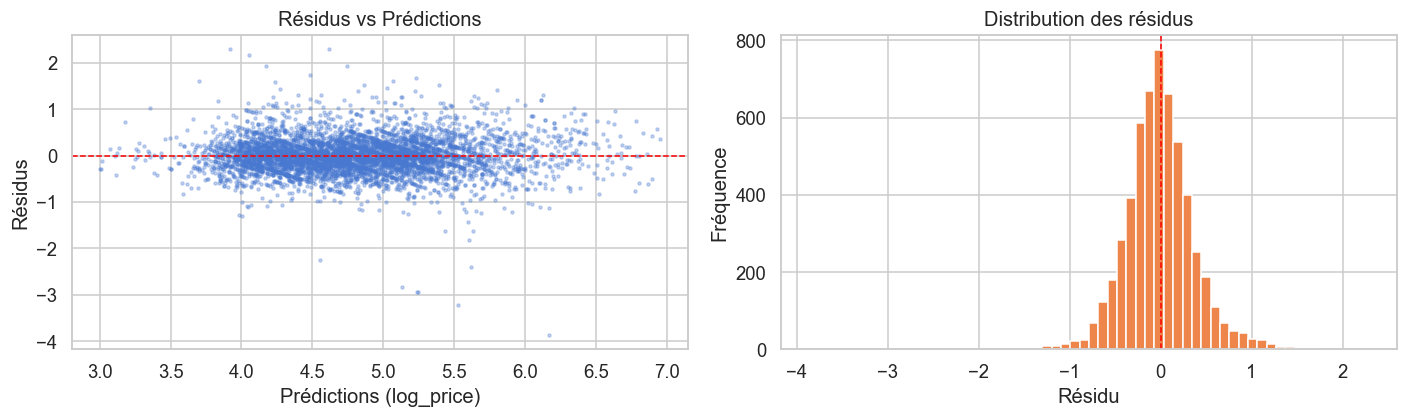

Résidu moyen : -0.0046
Résidu std   : 0.3863


In [165]:
y_pred_val = best_model.predict(X_val)
residuals  = y_val - y_pred_val

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_pred_val, residuals, alpha=0.3, s=4, color=sns.color_palette('muted')[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Prédictions (log_price)')
axes[0].set_ylabel('Résidus')
axes[0].set_title('Résidus vs Prédictions')

axes[1].hist(residuals, bins=60, color=sns.color_palette('muted')[1], edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Résidu')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des résidus')

plt.tight_layout()
plt.show()

print(f"Résidu moyen : {residuals.mean():.4f}")
print(f"Résidu std   : {residuals.std():.4f}")

**Analyse des résidus :**
- Les résidus sont centrés autour de 0 : pas de biais systématique.
- La distribution est approximativement gaussienne : hypothèse de normalité respectée.
- Quelques outliers existent (logements très atypiques difficiles à prédire).

## 4.3 Prédiction finale

On applique l'ensemble du pipeline au fichier **airbnb_test.csv** et on génère **MaPredictionFinale.csv**.

In [166]:
df_test_raw = pd.read_csv('airbnb_test.csv')

df_test_processed = build_features(df_test_raw, base_prep, amenities_enc, date_feats, text_feats, geo_feats, fit=False)
X_test_final = get_X(df_test_processed)

unnamed_cols = [c for c in X_test_final.columns if c.startswith('Unnamed')]
if unnamed_cols:
    X_test_final = X_test_final.drop(columns=unnamed_cols)
X_test_final = X_test_final[X_train.columns]

y_final = best_model.predict(X_test_final)

test_ids = df_test_raw.iloc[:, 0]

submission = pd.DataFrame(
    {'logpred': y_final},
    index=test_ids.loc[X_test_final.index].values
)
submission.index.name = None
submission.to_csv('MaPredictionFinale.csv')

print(f"MaPredictionFinale.csv généré — {len(submission):,} prédictions")
print(f"log_price prédit : min={y_final.min():.2f}  max={y_final.max():.2f}  moy={y_final.mean():.2f}")

MaPredictionFinale.csv généré — 51,877 prédictions
log_price prédit : min=2.85  max=7.21  moy=4.79


## 4.4 Validation du fichier de soumission

In [167]:
def estConforme(filepath):
    df = pd.read_csv(filepath, index_col=0)
    ok = True
    if 'logpred' not in df.columns:
        print("Colonne 'logpred' manquante")
        ok = False
    if len(df) != 51877:
        print(f"Nombre de lignes incorrect : {len(df)} (attendu : 51877)")
        ok = False
    if df['logpred'].isna().any():
        print(f"{df['logpred'].isna().sum()} valeurs manquantes dans logpred")
        ok = False
    if ok:
        print("Fichier conforme !")
    return ok

estConforme('MaPredictionFinale.csv')

Fichier conforme !


True